## INFO ABOUT THIS PROJECT

When I was looking for datasets to showcase my skills and understanding of experimentation, I could not really find one that felt suitable for what I wanted to show.  
For this reason, I decided to use one of my old work projects instead and reflect on how I would design it differently today in order to make it statistically more reliable.  
Hence, the aim of this project is to show that I understand how to properly design an experiment, define the right metrics, set decision criteria upfront, and evaluate the results in a statistically sound way.

## INTRODUCING THE WORK PROJECT

<div style="font-size: 16px;">
  <div style="display: flex; align-items: flex-start; gap: 20px; justify-content: flex-start;">
    <div style="width: 1500px; font-size: 16px;">
      <h3 style="font-size: 16px;">HYPOTHESIS:</h3>
      <p><b>We believe that if we distribute our workforce equally throughout the weekdays, we will be able to have improved SLAs on weekends.</b></p>
      <p>Each month we are forecasting the amount of tickets we will receive on a monthly level and distribute the ticket volume per week, per day and on an intraday level. For each level we are using a specific factor, which is basically the share for a specific week within a year, the share of a day within a week and hourly share within a day.</p>
      <p>We wanted to run a test on the day-of-week factor (DOW). As you can see in the chart on the right, historically the DOW follows a downward trend.</p>
      <p>The average of those weeks could look like on the right.</p>
    </div>

  <div style="display: flex; gap: 20px; align-items: flex-start;">
      <img src="../pics/total_DOW.png" width="350" />
      <img src="../pics/DOW_old.png" width="250" />
    </div>
  </div>

  <p>The DOW is used to distribute the weekly ticket volume between the days within a week based on their share (DOW).</p>
  <p>We then convert the daily forecasted ticket volume into FTE requirements - so how many customer support agents we would need for a specific day.</p>
  <p>Based on the DOW factor our FTE requirement could look something like this:</p>

  <div style="width: 250px;">
    <img src="../pics/DOW_fte.png" width="250" />
  </div>

  <p>Which means that we require less agents on the weekend.</p>

  <div style="margin-top: 10px; margin-bottom: 20px;">
    <img src="../pics/DOW_weekday.png" width="900" />
  </div>

  <p>The chart above shows the SLA we wanted to improve, namely the FRT (full resolution time excl. pending).<br>
  Each day we are tracking the full resolution time of tickets that were solved under 24 hours and our goal is to have it at 70%.</p>

  <p>We have noticed that the SLA is lower on Saturdays, Sundays and Mondays compared to the other days. This is due to multiple reasons:</p>

  <p>1. We are forecasting the FTE requirement based on newly created tickets, which means we basically assume that agents will solve new tickets the same day they were created, which is not always the case.</p>

  <p>2. In addition to new tickets, we also have tickets that were in status pending for a few days and might reopen once a member has replied.<br>
  Such tickets will show up in the backlog again and increase it. However, such tickets are not considered in our forecast at the moment.</p>

  <p>Because our forecast is based only on newly created tickets, we wanted to test if the SLA would improve for the weekends if we distribute the agents evenly throughout the week.<br> 
  With more agents on the weekend, we could tackle more tickets and therefore improve the share of tickets solved within 24 hours (FRT excluding pending) for the weekend as well.<br>
  This is because we not only get new tickets, but also tickets that reopened after being in pending status.</p>

  <p>FRT excl. pending is the time in hours it took for a ticket to get completely solved, but it excludes the hours the ticket has spent in pending status.<br>
  So the hours the ticket was waiting for a reply from member. <br>
  It only consists of the hours an agent was working on the ticket.</p>
</div>

## HOW WE DID IT AND WHAT WAS MISSED

<div style="font-size: 16px;">
  <p>
    At that time, we did not treat this project as a statistically planned A/B test, but rather as an explorative operational test.<br> 
    The idea was to check whether weekend SLA performance could improve, if we distributed the DOW factor more evenly across the week, instead of following the usual downward weekend trend.<br> 
    We applied the change in selected markets, kept other markets running as usual, and let the test run for one month.<br> 
    After the month ended, we collected the data, created charts, compared the main metrics between treatment and control, and then made a decision mainly based on visual comparison and intuition.
  </p>

  <p>
    The main problem was not the idea of the test itself, but the fact that we had not properly planned the experiment beforehand.<br> 
    We only had the general goal in mind, which was to see whether FRT on weekends would improve.<br> 
    However, we did not define in advance how exactly we wanted to evaluate success, which metrics should be most important, how long the test should run, or what result would actually be strong enough for us to scale the change.<br> 
    This became especially difficult at the end of the test, because additional metrics were requested only after the experiment had already finished.<br> 
    As a result, the final evaluation became more complicated than necessary, because some metrics looked good, while others looked worse, and we had no clear framework for how to interpret such mixed results.
  </p>

  <p><u>What was missing in the original setup:</u></p>

  <ul>
    <li>a clearly defined statistical hypothesis before starting the test</li>
    <li>a proper metric hierarchy, meaning:
      <ul>
        <li>primary metric</li>
        <li>secondary metrics</li>
        <li>guardrail metrics</li>
      </ul>
    </li>
    <li>predefined decision rules for:
      <ul>
        <li>when to scale</li>
        <li>when not to scale</li>
        <li>or rerunning the test when results were inconclusive</li>
      </ul>
    </li>
    <li>a business-relevant MDE</li>
    <li>a sample size and test duration derived from historical variance and power assumptions instead of choosing the duration randomly</li>
    <li>which test statistic to use</li>
    <li>how to aggregate the data</li>
  </ul>

  <p>
    So overall, the project gave us a useful first business indication, but from today’s perspective it was not a statistically robust experiment.<br> 
    If we were to do it again, I would plan it much more rigorously upfront, define the metrics and decision rules upfront, estimate the required sample size before launch,<br> 
    and use a more suitable design and analysis framework to make the final decision more reliable.
  </p>
</div>

## HOW I WOULD DO IT TODAY

###  1. Define control, treatment and experimental design

<div style="max-width: 1100px; line-height: 1.6; font-size: 16px;">

  <p><b>Control:</b> current DOW factor based on historical created tickets<br>
  <b>Treatment:</b> equal DOW split across all weekdays</p>

  <p>
    Previously, we applied the treatment to two markets and each of them was compared to 2 other markets.
  </p>

  <p>
    So FR and UK were the treatment, but were individually compared with IT and ES.
    This means that FR was compared with IT &amp; ES and UK was also compared with IT &amp; ES.
  </p>

  <p>
    However, each market has a different number of agents with different proficiency levels. Furthermore, the ticket volume also differs across markets.
    FR and UK, for example, were much larger markets than IT and ES, both in terms of agent headcount and ticket volume.
  </p>

  <p>
    Because of this, I would not split the markets into one permanent treatment group and one permanent control group again.
    Because the comparison would be influenced by the characteristic differences in each market.
    Larger markets for example may have different ticket volume behavior, and different agent skill distributions than smaller ones.
    If one group performs better, it would be unclear whether this was really caused by the new DOW setup or simply by underlying market characteristics.
  </p>

  <p>
    For this reason, I would use a switchback design instead. In a switchback design, the same market operates once under control and once under treatment, but in different time periods.
    This means that every market serves as its own benchmark. As a result, fixed differences between markets, such as team structure, market size, or ticket complexity, have much less influence on the final comparison.
  </p>

  <p>
    This would make the experiment much more robust, because I would no longer mainly compare structurally different markets against each other, but instead compare the same market under two different staffing policies across time.
  </p>

  <p>
    In the original setup, only FR, UK, ES and IT were considered.
    Today, I would base how many markets to include in the test based on the needed sample size and how difficult or easy it would be to implement the test in the respective market.
    Hence, I would exclude markets where this implementation would be more difficult to achieve.
    If the needed sample size is big, including all markets would give us more observations per period and would therefore allow us to reach the required sample size faster.
    However, including all markets is not strictly necessary.
    What matters more is that the selected set of markets is large enough and sufficiently representative so that it reflects different market sizes, staffing structures, and ticket dynamics.
  </p>

  <p>
    Regarding the length of each switchback period, I would choose one full operational week.
    So one period would always run from Monday until Sunday.
    The reason for this is that the primary metric of interest is the weekend performance.
    If I switch the treatment at the beginning of the week, then Saturday and Sunday are fully part of one condition only, either control or treatment.
    This gives the staffing setup enough time to influence the queue dynamics before the metric is actually measured.
  </p>

  <p>
    The total number of periods would then depend on the required sample size and on how many markets are included in the test.
    Since the analysis would be done on a market-period level, every additional period gives us more observations.
    So the more periods we have, the more data points we can collect for control and treatment.
  </p>

  <p>
    The assignment of control and treatment across those periods should also be planned carefully.
    I would not use a simple setup such as first running all control weeks and then all treatment weeks, because this would make the test vulnerable to time effects such as seasonality or incidents.
    Instead, I would schedule it in a more balanced waz, meaning that each market would be in control and treatment multiple times throughout the experiment.<br>
    So for example like this: [Control, Treatment, Treatment, Control, Control, Treatment ...]
  </p>

  <p>
    For the final analysis, I would not only rely on visual comparison or on a standard t-test.
    From the literature I learned that for switchback experiments, the Fisher randomization test and the Neymanian approach are more suitable, so I would use both of them.
  </p>

  <p>
    Because, the fisher test is useful for checking whether there is evidence of any treatment effect at all, while the neymanian approach is useful for estimating how large this effect is likely to be.
    So in my opinion, both perspectives are valuable.
  </p>

</div>

### 2. Define the metric framework

<div style="max-width: 1100px; line-height: 1.6; font-size: 16px;">

  <p>
    Before the test we only cared about the FRT on the weekend. This was the metric we wanted to improve and test.
    However, we did not define any secondary or guardrail metrics before launching the test.
    Doing so would already have helped a lot with setting proper decision criteria upfront.
  </p>

  <p>
    Hence, today, I would first start with brainstorming sessions together with managers and colleagues in order to collect all relevant metrics and split them into primary, secondary and guardrail metrics.
  </p>

  <p>
    The reason is that since we are changing the staffing distribution, we should mainly evaluate metrics that are actually triggered by the staffing change. Otherwise, the whole test might focus on a metric that is only weakly linked to the intervention itself.
  </p>

  <p>
    The managers wanted to improve the weekend FRT and had the hypothesis that this could be influenced via staffing.
    This makes sense, because as Resource Analysts we can influence staffing, but not ticket complexity or ticket volume.
  </p>

  <p>Some other metrics we monitor and report daily are:</p>

  <ul style="margin-top: 0;">
    <li>load coverage (new tickets / solved tickets)</li>
    <li>reply/hour (how many replies a market was able to make within one hour, the higher the better)</li>
    <li>reply/ticket (how many replies it took to solve a ticket, the lower the better)</li>
    <li>idle time (how many hours of idle time were generated, meaning agents were available, but there were no assignable tickets in the queue)</li>
    <li>FiRT (first response time, which measures the time from ticket creation until an agent first replied)</li>
  </ul>

  <p>
    Since the project was originally about improving FRT, this metric would technically be the most obvious primary metric.
    However, today I would choose FiRT under 24 hours as the primary metric instead.
  </p>

  <p>
    The reason is that both FRT and FiRT are related to how quickly agents react to tickets, but FiRT is more directly touched by the staffing intervention.
    <br>If there are more agents available, tickets can be picked up faster and queue waiting time should decrease. This should affect FiRT first.
  </p>

  <p>
    FRT, on the other hand, is still more influenced by the type and complexity of the ticket.
  </p>

  <p>
    A more complex ticket may require the agent to check internal knowledge articles, investigate further or contact other parties before progressing the case. This agent-driven handling time still flows into FRT.
  </p>

  <p>
    However, FiRT is not fully independent from complexity either.
  </p>

  <p>
    If agents spend more time on difficult tickets, then other tickets remain longer in the queue, which also affects FiRT.
  </p>

  <p><b>But FiRT is computed as follows:</b></p>

  <p style="margin-left: 20px;">
    = Sum of newly created tickets within target / sum of all newly created tickets.
  </p>

  <p>
    Since our forecast is based on newly created tickets, it makes more sense to use the FiRT as the primary metric, as our staffing is based on newly created tickets, hence this metric is directly triggered more closely by this change.
  </p>

  <p>This leaves us with:</p>

  <ul>
    <li>Load coverage</li>
    <li>FRT</li>
    <li>rep/h</li>
    <li>rep/t</li>
    <li>Idle time</li>
  </ul>

  <p>
    Out of these, I would choose load coverage and FRT as the secondary metrics.
  </p>

  <p>
    I would choose the load coverage, because it helps to understand whether the new staffing setup actually improves the market’s ability to keep up with the ticket demand. Since it is calculated as newly created tickets divided by solved tickets, it gives a good view on whether the team is able to process the workload it receives. If the equal DOW setup works well, then this metric should improve, because more agents would be available on the weekend to solve tickets instead of letting them accumulate.
  </p>

  <p>
    Additionally I would also choose FRT as a secondary metric, because it would tell us whether improved first response time (picking tickets up faster) also translates into better resolution performance, at least for the parts that are agent-driven.
  </p>

  <p>
    I would remove reply/hour and reply/ticket from the evaluation, because they are heavily influenced by ticket type and complexity. Hence, if they should change, it would be difficult to say whether it was due to the treatment or simply due to different ticket behaviour during the observed period. They can still be used for diagnostics, but I wouldn’t choose them for making decisions.
  </p>

  <p>
    As for the guardrail metric, I would choose idle time. Since ticket volume is historically lower on weekends, it creates a potential risk of overstaffing. So agents could be ready to work, but no assignable tickets would be available in the queue. This would mean that the treatment improves operational service, but at the cost of non-productive hours.
  </p>

  <p>
    So overall, if I had to define the metric framework today, I would structure it as follows:
  </p>

  <ul>
    <li><b>Primary metric:</b> FiRT (under 24 hours)</li>
    <li><b>Secondary metrics:</b> load coverage and FRT excl. pending (under 24 hours)</li>
    <li><b>Guardrail metric:</b> idle time</li>
  </ul>
</div>

### 3. Define the decision criteria before the test

<div style="max-width: 1100px; line-height: 1.6; font-size: 16px;">

  <p>
    Before launching the test, we should have defined our decision criteria.
  </p>

  <p>
    Because last time we decided based on the results of multiple metrics, some were good and some were bad, it was rather difficult to suggest recommendations, as we took all of them into account. The decision should instead have been based mainly on the primary metric and the guardrail metric, while the secondary metrics should only support the interpretation.
  </p>

  <p><b>Today, I would suggest the following decision criteria:</b></p>

  <ul>
    <li>If FiRT improves significantly and there are no negative effects on idle time &rarr; <b>scale</b></li>
    <li>If FiRT improves but there is a negative effect on idle time &rarr; <b>do not scale, but investigate why it happened</b></li>
    <li>If FiRT remains neutral or negative &rarr; <b>do not scale</b></li>
  </ul>

  <p>
    However, I would not only evaluate the metrics on weekend level, but also on weekday level.
  </p>

  <p>
    The reason is that the equal DOW setup does not create additional capacity, but rather redistributes it across the week. This means that an improvement on Saturday and Sunday could come at the cost of weaker performance on weekdays. Since weekdays historically still receive the highest amount of newly created tickets, this trade-off should not be ignored.
  </p>

  <p>
    At the same time, a certain decline on weekdays could still be acceptable from a business perspective, as long as the weekend improvement is large enough to justify it. But this acceptable trade-off should be defined before the test starts. Otherwise, the final decision would again become subjective and depend too much on interpretation.
  </p>

  <p>
    Because of this, I would define not only the expected improvement on weekend level, but also the maximum acceptable deterioration on weekday level. For example, we could define that weekday FiRT is allowed to decline, but only up to a predefined threshold. This would make the final evaluation much clearer and more transparent.
  </p>

  <p><b>With this in mind, the decision criteria should rather look like this:</b></p>

  <ul>
    <li>If weekend FiRT improves significantly, weekday FiRT declines only within the accepted threshold, and idle time does not worsen, then <b>scale</b>.</li>
    <li>If weekend FiRT worsens, even if weekday FiRT and idle time remain neutral, then <b>do not scale</b>.</li>
    <li>If weekend FiRT remains neutral, but weekday FiRT improves and idle time remains neutral, then the result is <b>inconclusive</b> and should be investigated further.</li>
  </ul>

</div>

### 4. Estimate MDE, variance and sample size before launch

<div style="max-width: 1100px; line-height: 1.6; font-size: 16px;">

  <p>
    Another important point is that we did not define an MDE or estimated the required sample size before launching the test.<br>
    Instead, it was more or less intuitively decided to let it run for one month. From today’s perspective, this was a weakness, because when designing a statistical test, the runtime should not be chosen arbitrarily. It should be based on whether the test is sensitive enough to detect a business-relevant treatment effect if it actually exists.
  </p>

  <p>
    The first step would therefore have been to define the smallest treatment effect that would still be meaningful for the business.
  </p>

  <p>
    Let’s assume managers agreed to split the primary metric into Weekend-FiRT and Weekday-FiRT. Then the next question would be: what should the MDE be for each of them?
  </p>

  <p>
    In order to help make a decision, I would first analyze the historical baseline of both weekend and weekday FiRT and compare them with the current business target. For example, if historical weekend FiRT is clearly below target, then even an absolute improvement of a few percentage points could already be operationally meaningful. At the same time, if weekday FiRT is already much closer to target, then only a limited deterioration should be accepted.
  </p>

  <p>
    Secondly, I would estimate the variance of the primary metric.
  </p>

  <p>
    This is important because the variance tells us how noisy the metric is. The more the metric usually fluctuates, the harder it becomes to distinguish a true treatment effect from just normal variation. If the metric turned out to be too noisy, I would then check whether the metric itself, aggregation level, or transformation can be adjusted in order to improve the sensitivity of the test.
  </p>

  <p>
    And based on the MDE, the standard deviation, and predefined and agreed upon alpha and beta, I would estimate the required sample size and runtime. This would make the test duration statistically justified instead of operationally arbitrary.
  </p>

</div>

## A/A Test

So far, I have discussed what was missing in the original setup and how I would redesign the test today.  
This included the experimental design, the metric framework, the decision criteria and the estimation of MDE, variance and sample size.  

The next step is now to check whether these ideas also hold up in practice.  
For this, I will run an A/A test on historical data.  
The goal is not to measure a real treatment effect, but to check whether the proposed setup is statistically valid and whether the chosen methodology behaves as expected when no real treatment is present.  

In other words, I now want to test whether the randomization itself creates artificial differences or whether the setup is robust enough to be trusted for a real experiment.  
The following analysis is therefore meant to validate the design and analysis choices discussed above.  

Since one period runs from Monday to Sunday, I would calculate the primary metric for each market and each period by combining Saturday and Sunday.

So for each market in each week, I would sum up all weekend tickets that reached the target and divide them by the total amount of newly created weekend tickets:

$$
WeekendFiRT_{m,p} = \frac{ReachedTickets_{Sat+Sun}}{CreatedTickets_{Sat+Sun}}
$$

This means that the analysis would not be done on ticket level and also not on single-day level, but on the aggregated weekend level per market and period.

In [1]:
# Importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [2]:
url = '/Users/eliza.cekavice/Documents/AB/DOW.csv'

data = pd.read_csv(url)

data.head()

,week,date,day,market,created_tkt,reached_tkt,FiRT
0,2026-04-13,2026-04-19,Sunday,FR,423,214,0.5059
1,2026-04-13,2026-04-19,Sunday,DE,65,42,0.6462
2,2026-04-13,2026-04-19,Sunday,EN III,656,447,0.6814
3,2026-04-13,2026-04-19,Sunday,EN II,1916,1174,0.6127
4,2026-04-13,2026-04-19,Sunday,IT,9,5,0.5556


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6174 entries, 0 to 6173
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   week         6174 non-null   object 
 1   date         6174 non-null   object 
 2   day          6174 non-null   object 
 3   market       6174 non-null   object 
 4   created_tkt  6174 non-null   int64  
 5   reached_tkt  6174 non-null   int64  
 6   FiRT         6174 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 337.8+ KB


In [4]:
# changing the data type of week and date to datetime for efficient handling

dato = ['week', 'date']

for i in dato:
    data[i] = pd.to_datetime(data[i])

In [5]:
# creating a table for the weekend FiRT per market and week

weekend_data = data[(data['day'] == 'Saturday') | (data['day'] == 'Sunday')]

weekend_sla = (weekend_data.groupby(['week', 'market'], as_index=False).agg(created_tkts=('created_tkt', 'sum'),reached_tkts=('reached_tkt', 'sum')))

weekend_sla['FiRT'] = weekend_sla['reached_tkts'] / weekend_sla['created_tkts']

weekend_sla

,week,market,created_tkts,reached_tkts,FiRT
0,2023-11-20,DE,630,512,0.812698
1,2023-11-20,EN I,4477,2549,0.569354
2,2023-11-20,EN II,11870,10575,0.890901
3,2023-11-20,EN III,1493,1035,0.693235
4,2023-11-20,ES,1953,452,0.231439
...,...,...,...,...,...
877,2026-04-13,EN II,4606,2967,0.644160
878,2026-04-13,EN III,2077,1269,0.610977
879,2026-04-13,ES,147,48,0.326531
880,2026-04-13,FR,1593,832,0.522285


In [6]:
weekend_sla['FiRT'].describe()

count    882.000000
mean       0.567584
std        0.250756
min        0.026567
25%        0.349852
50%        0.592939
75%        0.796251
max        0.961404
Name: FiRT, dtype: float64

In [7]:
# creating a table to look at the weighted statistics of FiRT, where the weights are the number of created tickets per market and week.

x = weekend_sla['FiRT']
w = weekend_sla['created_tkts']

weighted_mean = np.average(x, weights=w)
weighted_variance = np.average((x - weighted_mean) ** 2, weights=w)
weighted_std = np.sqrt(weighted_variance)
weighted_min = x.min()
weighted_max = x.max()

weighted_summary = pd.DataFrame({
    'statistic': ['weighted_mean', 'weighted_variance', 'weighted_std', 'min', 'max'],
    'value': [weighted_mean, weighted_variance, weighted_std, weighted_min, weighted_max]
})

weighted_summary

,statistic,value
0,weighted_mean,0.519438
1,weighted_variance,0.070459
2,weighted_std,0.265441
3,min,0.026567
4,max,0.961404


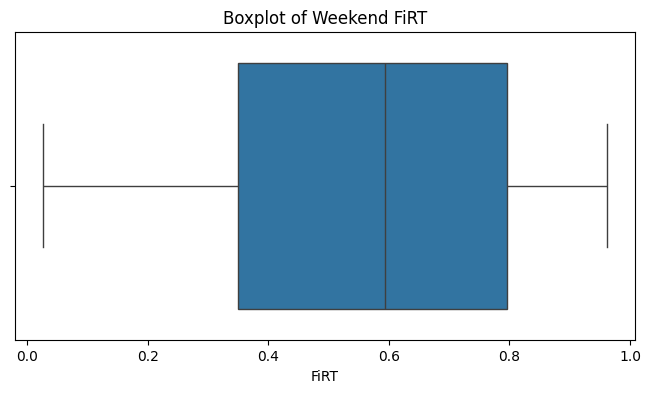

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=weekend_sla['FiRT'])
plt.title('Boxplot of Weekend FiRT')
plt.show()

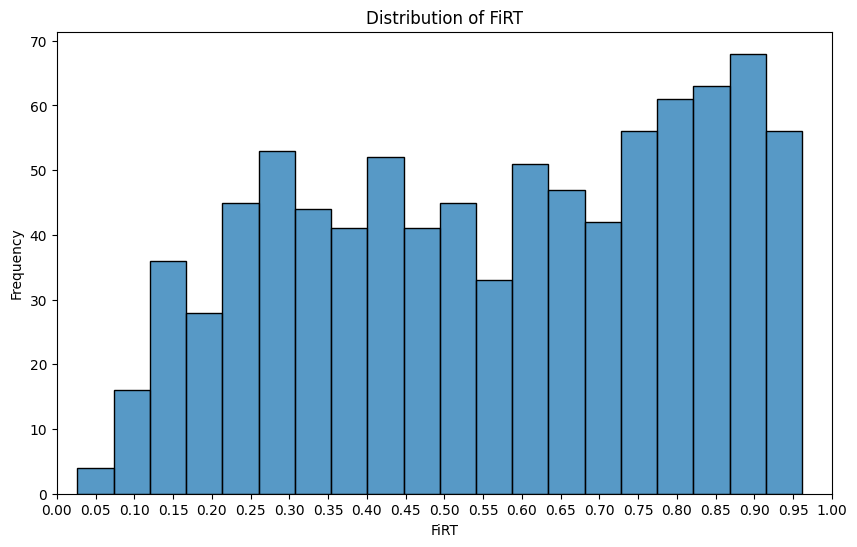

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(data=weekend_sla,x='FiRT', bins=20)
plt.title('Distribution of FiRT')
plt.xlabel('FiRT')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.01, 0.05)) 
plt.show()

While the average the FiRT on the weekend is around 56.76%, the weighted average is 51.94%.  
Meaning markets with higher created ticket volume tend to have lower FiRT.  
Based on the boxplot we don't have any outliers.
Which is also visible in the histogram, as the values don't follow a null distribution.  
The values vary widely, aka the metric is unfortunately very noisy, as the values could be anywhere between 6% to 96%. And this is a very huge range.  
The weighted standard deviation is 26.54%, meaning we will most likely require a large sample size to be able to detect the treatment effect.  

In [10]:
# required sample size for Neymanian test

# I would use the sample size formula for a continuous metric rather than for a conversion metric. 
# Even though FiRT is conceptually a success rate, the actual observations used in the test are not binary outcomes, but continuous market-period level proportions such as 0.52, 0.61 or 0.48.

alpha = 0.05
beta = 0.20
z_alpha = 1.96
z_beta = 0.84

s = 0.2651
delta = 0.05

n_per_arm = (2 * (z_alpha + z_beta)**2 * s**2) / (delta**2)
print(n_per_arm)


440.7836787199999


So for the neymanian test we would need 882 datapoints, 441 for control and 441 for treatment.  

Since per one period we could potentially have observations for 7 markets (if we decide to include all markets), it would mean we would need 126 weeks and therefore ~ 32 months to collect this sample size, which are 2.7 years.  
This is unfortunately a very long time and would pose difficulties for us.  

We are creating the FTE requirement manually and it would require too much manual effort to always send out the new FTE requirement based on the randomization pattern of the switchback test.  
Secondly, there are always shrinkages, meaning agents get sick or need urgent vacation etc, which reduces the available agent amount and therefore disrupts the equal DOW logic.  

Doing this test for 2 weeks or up to a month is more feasible. We can have a special agreement in place with our vendors for a short period of time, but forcing vendors to do this for 2.7 years only to find out that the treatment doesn't work is contra productive.  

Hence, I would try to reduce the variance of the weekend FiRT metric.  

My ideas are:  
- transforming the metric into a binary variable. 
- adjusting the aggregation level, for example by separating Saturday and Sunday instead of combining them into one weekend metric, if both days behave differently.
- choosing a different metric with lower variance, which might be closer to the actual trigger event.

#### Binary transformation:  

Instead of using the exact FiRT value, we would only check whether the target was reached or not, for example 1 = target reached and 0 = target not reached.  
The benefit of this is that the metric becomes easier to interpret from a business point of view and extreme values would have less influence.  

However, the downside is that we would lose information.
For example, a period with 69% FiRT and one with 20% FiRT would both be treated the same as 0, although operationally they are clearly not the same.

From a testing perspective, this would still work with both Fisher and Neymanian.
For Fisher this is not really an issue, because the test mainly relies on the randomization itself.
For Neymanian it would also work, but then the estimated treatment effect would no longer describe the change in the actual FiRT level, but only the change in the share of periods that reached the target.

In [11]:
# transforming FiRT into a binary variable based on a threshold of 70%

weekend_sla['FiRT_binary'] = np.where(weekend_sla['FiRT'] >= 0.7, 1, 0)
std_binary = weekend_sla['FiRT_binary'].std()
mean_binary = weekend_sla['FiRT_binary'].mean()

print(f"std = {std_binary}, mean = {mean_binary}")

std = 0.48388066391423096, mean = 0.373015873015873


The variance of a binary metric is highest when the share of 1s is around 50%, and smaller when it is closer to 0% or 100%.  
In our case, the share of target reached is 37.30%, so the binary version still contains substantial variation.

There are also other transformation methods, such as capping or log transformation, but neither of them seems particularly suitable here.  

1. capping is useful when a metric contains a few extreme values that heavily distort the distribution. In my case, the boxplot did not show such extreme outliers, so capping would likely not address the actual source of noise.

2. and Log transformation is more suitable for strongly right-skewed metrics with long tails. My metric however does not suffer from extreme tail values.  In my case, the main problem seems to be structural market differences rather than a purely skewed metric. 


Therefore we are currently left with two options:  
1. separating Saturday and Sunday data.

2. finding and defining a new metric, which is closely touched by the headcount adjustments. However, this would require to do a deeper analysis.  

3. accepting the required sample size.

Let's assume everybody agreed on the current setup:  

- We're doing the test on 7 markets
- We are using FiRT (Sat + Sun)
- We accept the variance of the primary metric and therefore
- will collect data for 126 weeks and divide it into treatment and control
- and assign each market the following switchback design randomly:

[C, T, T, C, C, T, T, C ....]

C = Control / T = Treatment

So we would allow the same phase to appear twice in a row, because switching the setup every single week would create too much manual effort on our side  
and would be harder to maintain in practice.  

In order to avoid that all markets start with the exact same condition in week 1, we would randomly shift the starting point of this pattern for each market.  

So one market could start with control in week 1, while another one could start with treatment.  

Furthermore we agree on an alpha of 5% and beta of 20%.

An alpha of 5% means that we accept a 5% risk of rejecting the null hypothesis even though it is actually true.  

A beta of 20% means that we accept a 20% risk of failing to reject the null hypothesis even though it is actually false.

In [12]:
# random assignment of markets to control and treatment groups using our fixed switchback design

def rotate_pattern(pattern, shift):
    shift = shift % len(pattern)
    return pattern[shift:] + pattern[:shift]

def generate_fixed_switchback_sequence(n_periods, pattern):
    sequence = []
    while len(sequence) < n_periods:
        sequence.extend(pattern)
    return sequence[:n_periods]

base_pattern = ['Control', 'Treatment', 'Treatment', 'Control']


market_shifts = {
    'FR': 0,
    'ES': 1,
    'IT': 2,
    'DE': 3,
    'EN1': 0,
    'EN2': 1,
    'EN3': 2
}

def assign_switchback(group):
    market_name = group['market'].iloc[0]
    shift = market_shifts.get(market_name, 0)

    rotated_pattern = rotate_pattern(base_pattern, shift)

    group = group.sort_values('week').copy()
    seq = generate_fixed_switchback_sequence(
        n_periods=len(group),
        pattern=rotated_pattern
    )
    group['assignment'] = seq
    return group


assignments = []
for market, group in data[['market', 'week']].drop_duplicates().groupby('market'):
    group = group.copy()
    group['market'] = market
    out = assign_switchback(group)
    assignments.append(out)

assignments = pd.concat(assignments, ignore_index=True)
assignments = assignments[['market', 'week', 'assignment']]


data = data.merge(assignments, on=['market', 'week'], how='left')


data.head(20)

,week,date,day,market,created_tkt,reached_tkt,FiRT,assignment
0,2026-04-13,2026-04-19,Sunday,FR,423,214,0.5059,Treatment
1,2026-04-13,2026-04-19,Sunday,DE,65,42,0.6462,Control
2,2026-04-13,2026-04-19,Sunday,EN III,656,447,0.6814,Treatment
3,2026-04-13,2026-04-19,Sunday,EN II,1916,1174,0.6127,Treatment
4,2026-04-13,2026-04-19,Sunday,IT,9,5,0.5556,Control
5,2026-04-13,2026-04-19,Sunday,ES,57,17,0.2982,Treatment
6,2026-04-13,2026-04-19,Sunday,EN I,1264,765,0.6052,Treatment
7,2026-04-13,2026-04-18,Saturday,FR,1170,618,0.5282,Treatment
8,2026-04-13,2026-04-18,Saturday,ES,90,31,0.3444,Treatment
9,2026-04-13,2026-04-18,Saturday,EN III,1421,822,0.5785,Treatment


In [13]:
# aggregating weekend ticket data on week x market x assignment level and calculate Weekend-FiRT


weekend_data = data[data['day'].isin(['Saturday', 'Sunday'])].copy()

weekend_firt_table = (
    weekend_data
    .groupby(['week', 'market', 'assignment'], as_index=False)
    .agg(
        weekend_created_tkt=('created_tkt', 'sum'),
        weekend_reached_tkt=('reached_tkt', 'sum')
    )
)

weekend_firt_table['weekend_FiRT'] = (
    weekend_firt_table['weekend_reached_tkt'] / weekend_firt_table['weekend_created_tkt']
)

weekend_firt_table.head(20)

,week,market,assignment,weekend_created_tkt,weekend_reached_tkt,weekend_FiRT
0,2023-11-20,DE,Control,630,512,0.812698
1,2023-11-20,EN I,Control,4477,2549,0.569354
2,2023-11-20,EN II,Control,11870,10575,0.890901
3,2023-11-20,EN III,Control,1493,1035,0.693235
4,2023-11-20,ES,Treatment,1953,452,0.231439
5,2023-11-20,FR,Control,11862,2200,0.185466
6,2023-11-20,IT,Treatment,4047,1771,0.437608
7,2023-11-27,DE,Control,784,570,0.727041
8,2023-11-27,EN I,Treatment,4781,3428,0.717005
9,2023-11-27,EN II,Treatment,12552,10203,0.812859


In [14]:
# Fisher test

def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

def fisher_statistic(df):
    treatment = df[df['assignment'] == 'Treatment']
    control = df[df['assignment'] == 'Control']

    mean_t = weighted_mean(treatment['weekend_FiRT'], treatment['weekend_created_tkt'])
    mean_c = weighted_mean(control['weekend_FiRT'], control['weekend_created_tkt'])

    return mean_t - mean_c

observed_diff = fisher_statistic(weekend_firt_table)
print('Observed difference (Treatment - Control):', observed_diff)


rng = np.random.default_rng(42)

def permute_within_market(df, rng):
    df_perm = df.copy()

    permuted_assignments = []

    for market, group in df_perm.groupby('market'):
        labels = group['assignment'].to_numpy().copy()
        rng.shuffle(labels)
        permuted_assignments.extend(labels)

    df_perm['perm_assignment'] = permuted_assignments
    return df_perm

def fisher_statistic_perm(df):
    treatment = df[df['perm_assignment'] == 'Treatment']
    control = df[df['perm_assignment'] == 'Control']

    mean_t = weighted_mean(treatment['weekend_FiRT'], treatment['weekend_created_tkt'])
    mean_c = weighted_mean(control['weekend_FiRT'], control['weekend_created_tkt'])

    return mean_t - mean_c

n_permutations = 5000
perm_diffs = []

for _ in range(n_permutations):
    df_perm = permute_within_market(weekend_firt_table, rng)
    perm_diffs.append(fisher_statistic_perm(df_perm))

perm_diffs = np.array(perm_diffs)

fisher_p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print('p-value:', fisher_p_value)

Observed difference (Treatment - Control): -0.0041568360696023765
p-value: 0.848


A p-value of 0.8732 is exactly what we want.  
It means that there is a probility of 84.80% to receive the observed difference between cotrol and treatment, in our case -0.00416, under the assumption that the null hypothesis is true.  
Hence we can't reject the null hypothesis and this is exactly what we want, because in an A/A test no real treatment effect should be present.  
Meaning we could use this switchback pattern for assigning the weeks in control or treatment.

In [15]:
# Neymanian test

import pandas as pd
import statsmodels.formula.api as smf


df = weekend_firt_table.copy()

df['treat'] = (df['assignment'] == 'Treatment').astype(int)

model = smf.wls(
    formula='weekend_FiRT ~ treat',
    data=df,
    weights=df['weekend_created_tkt']
).fit(cov_type='HC1')

print(model.summary())

                            WLS Regression Results                            
Dep. Variable:           weekend_FiRT   R-squared:                       0.000
Model:                            WLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.02637
Date:                Sun, 26 Apr 2026   Prob (F-statistic):              0.871
Time:                        17:44:14   Log-Likelihood:                -300.64
No. Observations:                 882   AIC:                             605.3
Df Residuals:                     880   BIC:                             614.8
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5215      0.018     29.420      0.0

The results also show our design is statistically reliable.  
The estimated treatment effect is again very close to 0 (-0.0042), and the p-value of 87.1% shows that such an estimate is highly plausible under the null hypothesis.  
Furthermore the confidence interval contains 0 in it's range [-0.054 ; 0.046], solidifying that we can't reject the null hypothesis.   
So based on the Neymanian approach, there is no evidence that the setup itself creates an artificial difference between control and treatment.  